# 1. 模型的 profile 属性

In [4]:
from langchain_openrouter import ChatOpenRouter
from rich import print as rprint
from dotenv import load_dotenv
import os

load_dotenv(override=True)

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
OPENROUTER_API_BASE = os.getenv("OPENROUTER_API_BASE")

# 获取大模型
model = ChatOpenRouter(
    model='~x-ai/grok-latest',
    api_key=OPENROUTER_API_KEY,    # type: ignore
    base_url=OPENROUTER_API_BASE,
    max_tokens=1000
)

rprint(model.profile)

{
    'name': 'Grok Latest',
    'release_date': '2026-07-08',
    'last_updated': '2026-07-08',
    'open_weights': False,
    'max_input_tokens': 500000,
    'max_output_tokens': 1000000,
    'text_inputs': True,
    'image_inputs': True,
    'audio_inputs': False,
    'pdf_inputs': True,
    'video_inputs': False,
    'text_outputs': True,
    'image_outputs': False,
    'audio_outputs': False,
    'video_outputs': False,
    'reasoning_output': True,
    'tool_calling': True,
    'structured_output': True,
    'attachment': True,
    'temperature': True,
    'tool_call_streaming': True
}

# 2. 模型初始化的完整参数

In [ ]:
from rich import print as rprint

In [ ]:
from langchain_deepseek import ChatDeepSeek
from rich import print as rprint

rprint(ChatDeepSeek.model_fields.keys())

## 2.1 Deepseek 的完整参数
```json
dict_keys(['name', 'cache', 'verbose', 'callbacks', 'tags', 'metadata', 'custom_get_token_ids', 'rate_limiter', 
'disable_streaming', 'output_version', 'profile', 'client', 'async_client', 'root_client', 'root_async_client', 
'model_name', 'temperature', 'model_kwargs', 'openai_api_key', 'openai_api_base', 'openai_organization', 
'openai_proxy', 'request_timeout', 'stream_usage', 'max_retries', 'presence_penalty', 'frequency_penalty', 'seed', 
'logprobs', 'top_logprobs', 'logit_bias', 'streaming', 'n', 'top_p', 'max_tokens', 'reasoning_effort', 'reasoning',
'verbosity', 'tiktoken_model_name', 'default_headers', 'default_query', 'http_client', 'http_async_client', 
'http_socket_options', 'stream_chunk_timeout', 'stop', 'extra_body', 'include_response_headers', 'disabled_params',
'context_management', 'include', 'prompt_cache_options', 'service_tier', 'store', 'truncation', 
'use_previous_response_id', 'use_responses_api', 'api_key', 'api_base'])
```

## 2.2 model_kwargs

Langchain 接口没有的参数, 但是 OpenAI API 支持, 就可以通过 `model_kwargs` 声明额外参数

In [ ]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

load_dotenv()

model = init_chat_model(
    model="deepseek:deepseek-v4-pro",
    model_kwargs={
        # "thinking": {"type": "disabled"},   # DeepSeek 特有参数 不行
        "response_format": {"type": "json_object"}  # OpenAI 特有参数
    }
)

response = model.invoke(
    "把这段话提取成 JSON：张三，28 岁，住在北京。输出字段：name, age, city"
)
print(response.content)

{"name":"张三","age":28,"city":"北京"}


## 2.3 extra_body

如果 `model_kwargs` 是 LangChain 透传 OpenAI, 那么 `extra_body` 就是 OpenAI API 也不认识, 透传模型.

传的都是标准接口以外, 而模型支持的参数

In [ ]:
model = init_chat_model(
    model="deepseek:deepseek-flash",
    extra_body={"thinking": {"type": "disabled"}}
)

# 3. invoke config

1. 追踪信息走 config，模型参数走初始化或 model_kwargs，不要混用；
2. 团队规范里固定 metadata 的 key（如 user_id、session_id），LangSmith 排查效率会高很多；
3. config 会沿调用链自动传递——chain/agent 外层传一次，内部的模型、工具、检索器调用都会继承这些 tags 和 metadata，不需要每层手动传。

| 字段                | 作用                                         |
| ----------------- | ------------------------------------------ |
| `tags`            | 给这次运行打标签，LangSmith 里可筛选                    |
| `metadata`        | 附加元数据（如用户 ID、会话 ID），会显示在 LangSmith trace 里 |
| `run_name`        | 自定义这次运行在 LangSmith 里的显示名                   |
| `callbacks`       | 传入自定义回调（如流式打印、日志记录）                        |
| `configurable`    | 向链内部传递**动态运行时变量**（配合 `ConfigurableField`）  |
| `max_concurrency` | 批处理 `batch()` 时的并发上限                       |
| `recursion_limit` | Agent/图执行的最大步数限制（默认 25）                    |


In [8]:
from dotenv import load_dotenv
load_dotenv()

from langchain.chat_models import init_chat_model

model = init_chat_model(model="deepseek:deepseek-flash")

# 场景：多用户 RAG 服务，每次调用都带上追踪信息
response = model.invoke(
    "用一句话介绍 LangChain",
    config={
        "run_name": "intro-qa",                    # LangSmith 里好认
        "tags": ["production", "qa-v1"],           # 按版本/环境筛选
        "metadata": {                              # 业务侧上下文，排查问题时定位到具体用户
            "user_id": "refone",
            "session_id": "sess_abc123",
            "tenant": "acme-corp"
        },
    }
)

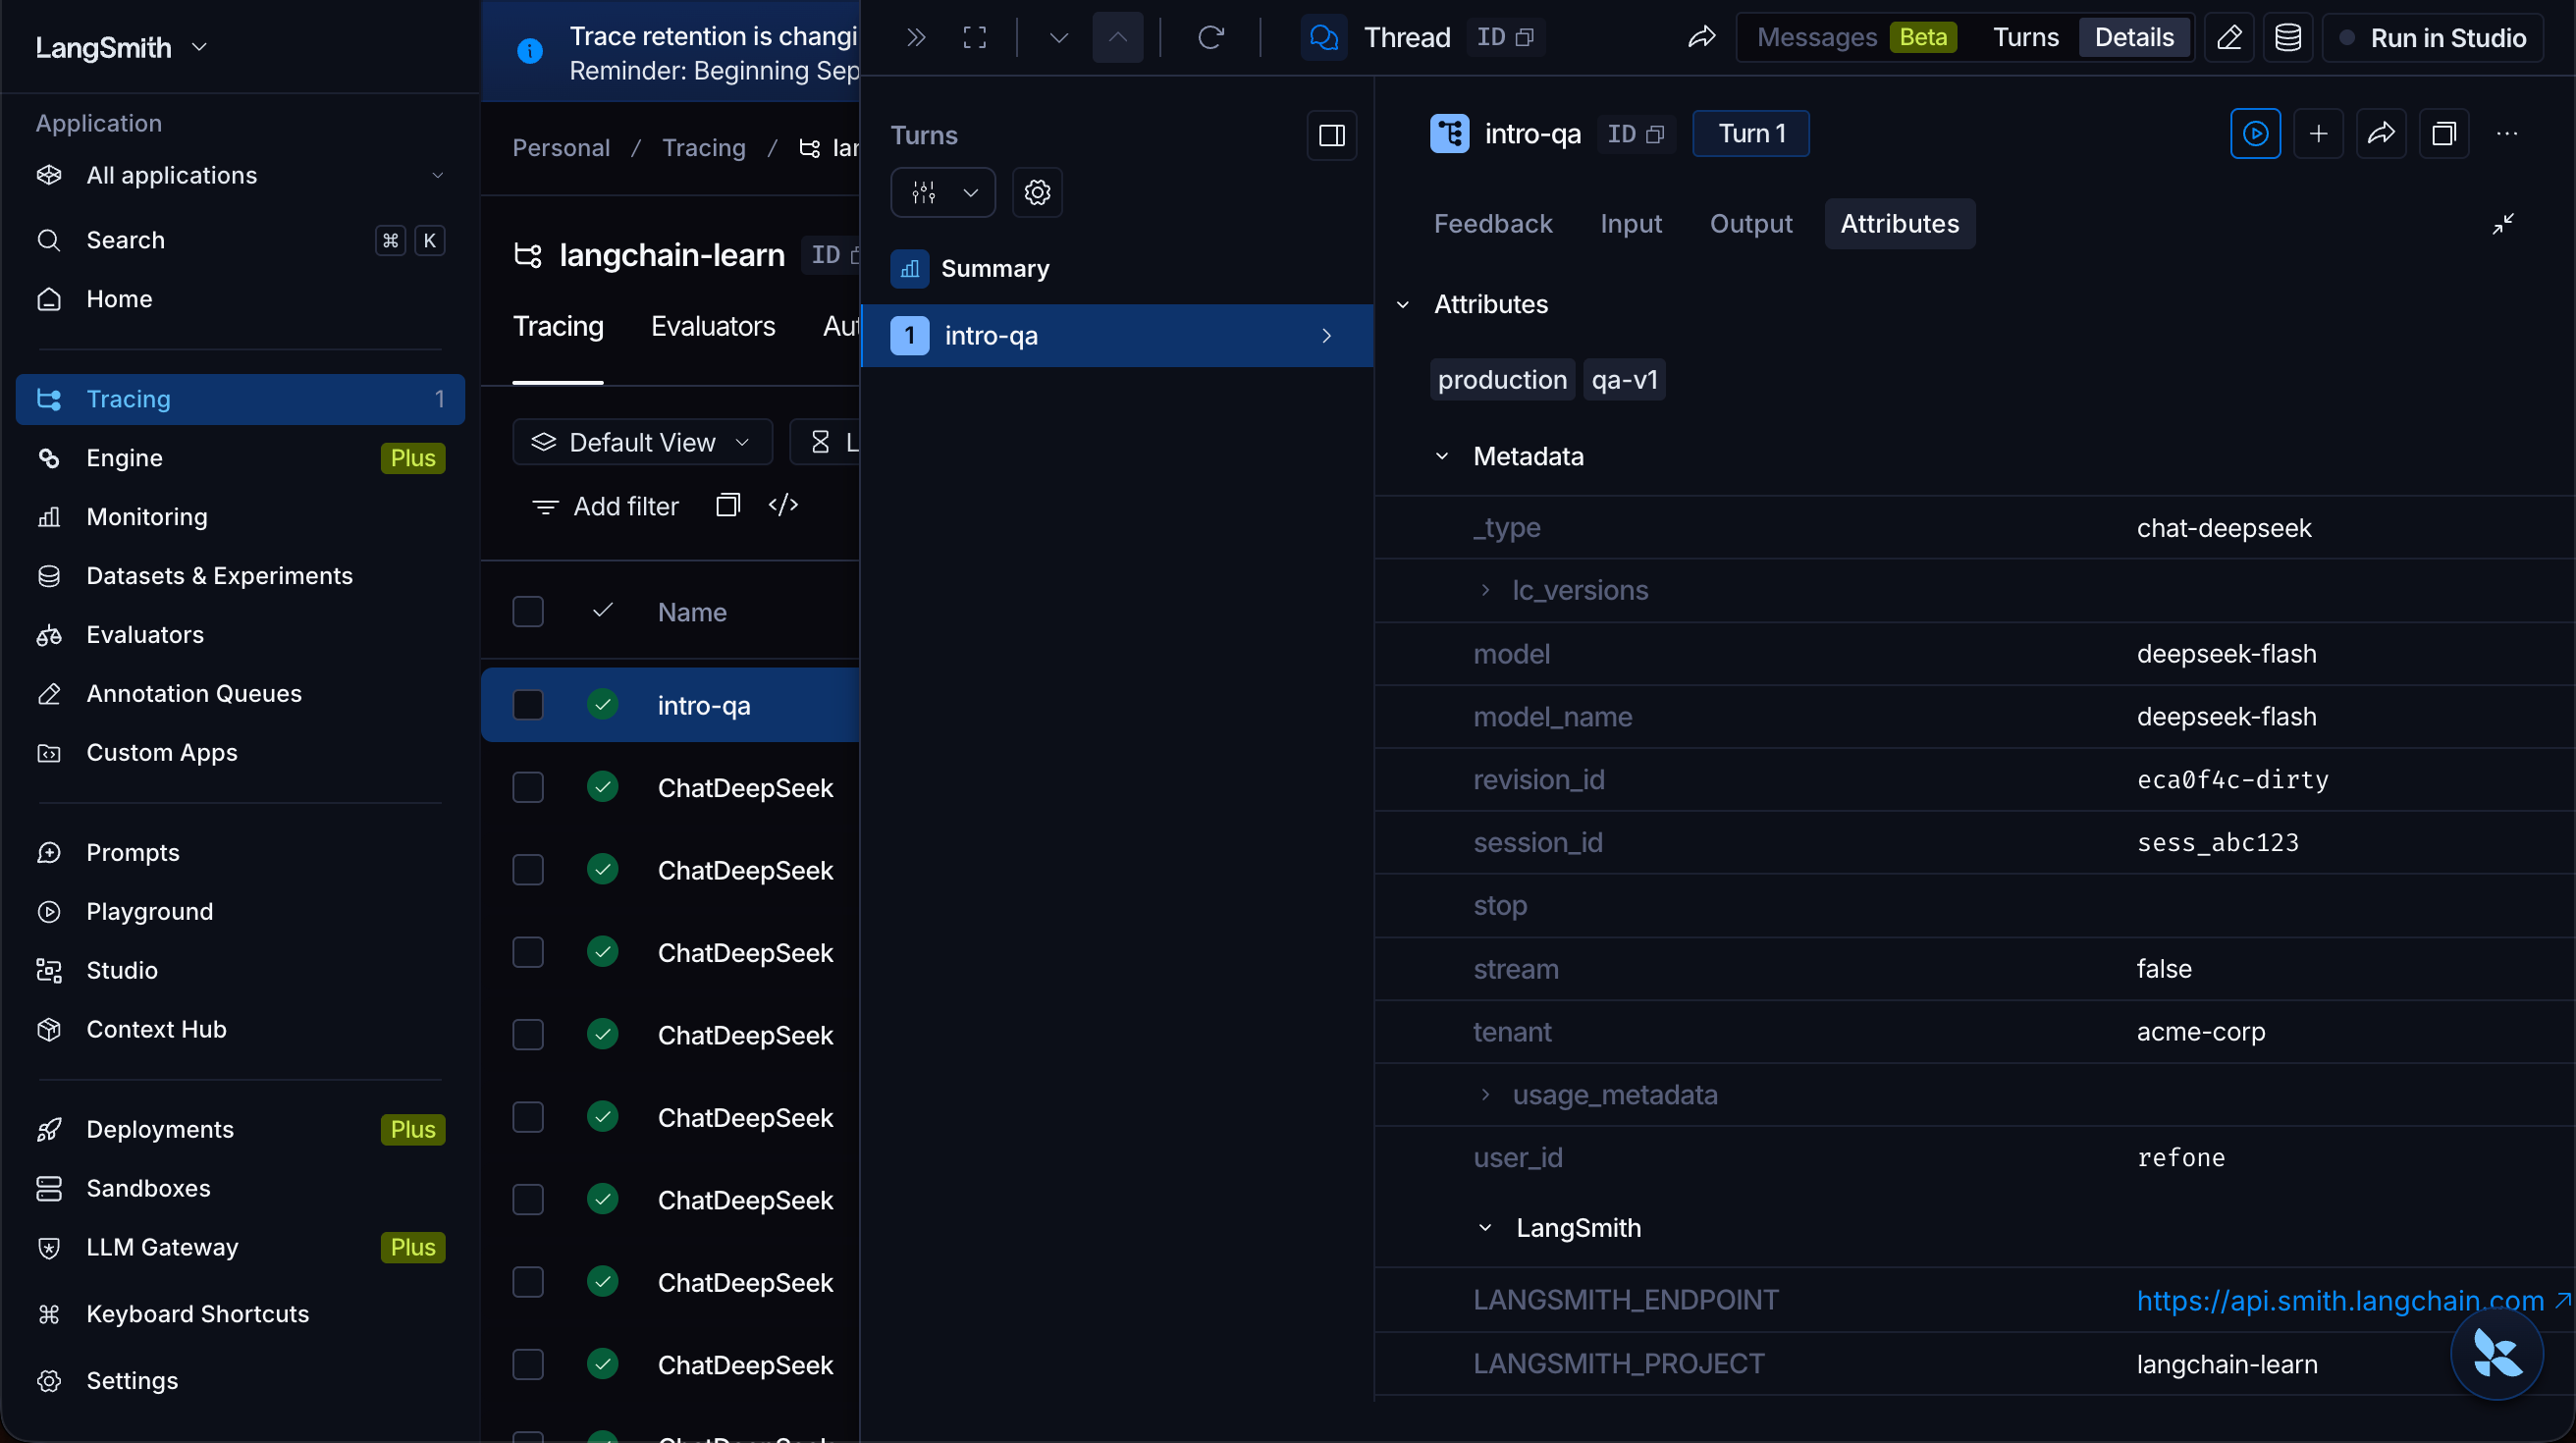

## configurable 动态切换链行为

调用时才确定模型的具体参数

### 生成控制类

| 字段                          | 类型         | 说明            |
| --------------------------- | ---------- | ------------- |
| `temperature`               | float      | 采样温度，0~2      |
| `max_tokens`                | int        | 最大输出 token 数  |
| `top_p`                     | float      | 核采样参数         |
| `stop`                      | list/str   | 停止序列          |
| `n`                         | int        | 一次返回几个候选回复    |
| `logprobs` / `top_logprobs` | bool / int | 返回 token 对数概率 |
| `streaming`                 | bool       | 是否流式输出        |

### 重试连接类

| 字段            | 说明                  |
| ------------- | ------------------- |
| `timeout`     | 请求超时时间（秒）           |
| `max_retries` | 失败重试次数              |
| `model`       | 模型 ID（可以动态切模型！）     |
| `api_key`     | 动态切换 API Key（多租户场景） |
| `base_url`    | API 端点              |


### 透传类

| 字段             | 说明                            |
| -------------- | ----------------------------- |
| `model_kwargs` | 整个字典（`thinking` 就藏在里面，只能整体替换） |


In [ ]:
from langchain_core.runnables import ConfigurableField

model = init_chat_model(model="deepseek:deepseek-flash").configurable_fields(
    temperature=ConfigurableField(id="temperature")
)

# 调用 A：精确模式
res1 = model.invoke("计算 123 * 456", config={
    "configurable": {
        "temperature": 0,
        }
    })
rprint(res1)

# 调用 B：创意模式 —— 同一个 model 对象，不改代码
res2 = model.invoke("写一首关于秋天的诗", config={
    "configurable": {
        "temperature": 1.3,
        }
    })
rprint(res2)

In [ ]:
model = init_chat_model(model="deepseek:deepseek-flash").configurable_fields(
    temperature=ConfigurableField(id="temperature"),
    max_tokens=ConfigurableField(id="max_tokens"),
    model_kwargs=ConfigurableField(id="model_kwargs"),
)

model.invoke(
    "...",
    config={"configurable": {
        "temperature": 0,
        "max_tokens": 2048,
        "model_kwargs": {"thinking": {"type": "disabled"}}
    }}
)